# 04 · Relational credit history: how much do the historical tables add?

> **Recovered experiment: acceptance incomplete (2026-09-21).** The original
> executed analysis below is preserved. See the [recovery audit](../reports/relational_recovery_audit.md)
> for unresolved future-dated bureau updates, incorrect individual-plot legends,
> and misleading analytical claims. Reproducing the recorded metrics does not
> certify temporal safety or Milestone 3 completion. No cells were re-executed
> during preservation; Milestone 2 remains the accepted primary model.


**Question.** Milestone 2 showed that the model class matters little once the
features are fixed: LightGBM and XGBoost reach ROC-AUC 0.762 on the 120 application
columns and are statistically tied. The remaining lever is *information*. This notebook
asks how much each historical table of the Home Credit dataset (credit-bureau records,
previous Home Credit applications, installment payments, credit-card and POS/cash
monthly balances) adds beyond `application_train.csv`, and what it does to probability
quality.

**Principle.** Same frozen Milestone 1 holdout, same frozen Milestone 2 LightGBM
configuration for every source comparison (a change in data, not a change in
hyper-parameters), every decision on the internal validation subset of the training
portion, the frozen test split scored once at the end. Section 10 audits this in code.

**Division of labour.** Feature engineering is `riskpilot.features.relational`
(`python -m riskpilot.features.relational.build`, cached to `data/processed/relational`),
the experiment is `riskpilot.models.relational_experiment` (ablation, light retuning,
frozen-test stage). The selection stages were run from the command line and their
machine-readable records are analysed here; the frozen-test comparison, the bootstrap
and the reference checks are *re-executed* in this notebook.

In [1]:
import inspect
import json
import logging

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from riskpilot import config
from riskpilot.data.load import categorize_strings, load_application_train, split_features_target
from riskpilot.features.relational import assemble
from riskpilot.models import challengers as ch
from riskpilot.models import comparison as cmp
from riskpilot.models import relational_experiment as rx
from riskpilot.models.evaluate import GRID_COLOR, MODEL_COLOR, REFERENCE_COLOR, SECOND_COLOR, calibration_table

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 90)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": GRID_COLOR,
        "axes.grid": True,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    }
)
paths = rx.RelationalPaths()
LABEL = cmp.LABELS
KEYS = ["roc_auc", "average_precision", "log_loss", "brier_score", "brier_skill_score",
        "expected_calibration_error", "calibration_slope", "calibration_intercept"]

## 1. The relational data model and the table grains

Verified on the downloaded files (`riskpilot.data.download --files relational`,
`artifacts/metrics/relational_raw_verification.json`) and in the builders' audits
(`relational_data_audit.json`). Every key relationship below was checked in code, not
assumed from the competition description.

In [2]:
raw = json.loads((config.METRICS_DIR / "relational_raw_verification.json").read_text(encoding="utf-8"))
audit = json.loads((config.METRICS_DIR / "relational_data_audit.json").read_text(encoding="utf-8"))
rows = []
for name, spec in config.RELATIONAL_TABLES.items():
    rows.append({"table": spec["filename"], "rows": raw[name]["n_rows"], "columns": raw[name]["n_columns"],
                 "size_mb": raw[name]["size_mb"], "keys": ", ".join(spec["keys"]), "grain": spec["grain"]})
display(pd.DataFrame(rows))
grain = {
    "bureau: SK_ID_BUREAU unique": audit["bureau"]["grain"]["sk_id_bureau_unique"],
    "bureau: customers": audit["bureau"]["grain"]["n_customers"],
    "bureau_balance: credits with monthly history / credits in bureau": f"{audit['bureau']['bureau_balance']['credits_in_bureau_with_history']:,} / {audit['bureau']['grain']['n_rows']:,}",
    "bureau_balance: duplicate (credit, month) rows": audit["bureau"]["bureau_balance"]["duplicate_credit_month_rows"],
    "previous: SK_ID_PREV unique": audit["previous"]["grain"]["sk_id_prev_unique"],
    "previous: customers": audit["previous"]["grain"]["n_customers"],
    "installments: rows sharing an installment key (split payments)": f"{audit['installments']['grain']['share_sharing_an_installment_key']:.2%}",
    "installments: customers / previous credits": f"{audit['installments']['grain']['n_customers']:,} / {audit['installments']['grain']['n_previous_credits']:,}",
    "credit_card: duplicate (card, month) rows": audit["credit_card"]["grain"]["duplicate_card_month_rows"],
    "credit_card: customers / cards": f"{audit['credit_card']['grain']['n_customers']:,} / {audit['credit_card']['grain']['n_cards']:,}",
    "pos: duplicate (contract, month) rows": audit["pos"]["grain"]["duplicate_contract_month_rows"],
    "pos: customers / contracts": f"{audit['pos']['grain']['n_customers']:,} / {audit['pos']['grain']['n_contracts']:,}",
}
display(pd.Series(grain, name="grain checks"))

,table,rows,columns,size_mb,keys,grain
0,bureau.csv,1716428,17,170.0,"SK_ID_CURR, SK_ID_BUREAU","one row per external credit (SK_ID_BUREAU), many per SK_ID_CURR"
1,bureau_balance.csv,27299925,3,375.6,"SK_ID_BUREAU, MONTHS_BALANCE, STATUS","one row per external credit and month (SK_ID_BUREAU, MONTHS_BALANCE)"
2,previous_application.csv,1670214,37,405.0,"SK_ID_PREV, SK_ID_CURR","one row per previous Home Credit application (SK_ID_PREV), many per SK_ID_CURR"
3,installments_payments.csv,13605401,8,723.1,"SK_ID_PREV, SK_ID_CURR, NUM_INSTALMENT_NUMBER","one row per (previous credit, installment, payment); split payments repeat"
4,credit_card_balance.csv,3840312,23,424.6,"SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE","one row per previous credit card and month (SK_ID_PREV, MONTHS_BALANCE)"
5,POS_CASH_balance.csv,10001358,8,392.7,"SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE","one row per previous POS/cash credit and month (SK_ID_PREV, MONTHS_BALANCE)"


bureau: SK_ID_BUREAU unique                                                        True
bureau: customers                                                                305811
bureau_balance: credits with monthly history / credits in bureau    774,354 / 1,716,428
bureau_balance: duplicate (credit, month) rows                                        0
previous: SK_ID_PREV unique                                                        True
previous: customers                                                              338857
installments: rows sharing an installment key (split payments)                    4.80%
installments: customers / previous credits                            339,587 / 997,752
credit_card: duplicate (card, month) rows                                             0
credit_card: customers / cards                                        103,558 / 104,307
pos: duplicate (contract, month) rows                                                 0
pos: customers / contracts      

## 2. Temporal semantics and leakage audit

Every time column in the six tables is expressed *relative to the current application
date* (official column dictionary). The audit records, per table, the minimum and
maximum of each `DAYS_*` / `MONTHS_BALANCE` column and the number of positive values,
which is what decides whether a column can describe the future. The five ambiguous
`previous_application` schedule columns are excluded outright.

In [3]:
temporal = []
for source, block in audit.items():
    for col, stats in block.get("temporal", {}).items():
        if isinstance(stats, dict):
            temporal.append({"source": source, "column": col, **{k: v for k, v in stats.items()}})
        else:
            temporal.append({"source": source, "column": col, "value": stats})
display(pd.DataFrame(temporal).fillna(""))
display(pd.DataFrame(audit["previous"]["excluded_temporal_detail"]).T.rename_axis("excluded column"))
print("installments lateness convention:", audit["installments"]["days_late_convention"])
catalog = pd.read_csv(config.METRICS_DIR / "relational_feature_catalog.csv")
display(catalog.groupby("source")["leakage_assessment"].first().to_frame())

,source,column,min,max,n_positive,value
0,bureau,DAYS_CREDIT,-2922.0,0.0,0.0,
1,bureau,DAYS_CREDIT_ENDDATE,-42060.0,31199.0,602603.0,
2,bureau,DAYS_ENDDATE_FACT,-42023.0,0.0,0.0,
3,bureau,DAYS_CREDIT_UPDATE,-41947.0,372.0,17.0,
4,previous,DAYS_DECISION,-2922.0,-1.0,0.0,
5,installments,DAYS_INSTALMENT,-2922.0,-1.0,0.0,
6,installments,DAYS_ENTRY_PAYMENT,-4921.0,-1.0,0.0,
7,credit_card,months_min,,,,-96.0
8,credit_card,months_max,,,,-1.0
9,pos,months_min,,,,-96.0


,n_missing,n_placeholder_365243,n_positive_real,min
excluded column,,,,
DAYS_FIRST_DRAWING,673065.0,934444.0,0.0,-2922.0
DAYS_FIRST_DUE,673065.0,40645.0,0.0,-2892.0
DAYS_LAST_DUE_1ST_VERSION,673065.0,93864.0,224392.0,-2801.0
DAYS_LAST_DUE,673065.0,211221.0,0.0,-2889.0
DAYS_TERMINATION,673065.0,225913.0,0.0,-2874.0


installments lateness convention: {'definition': 'DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT; positive = paid after due date', 'mean': -8.787405014038086, 'median': -6.0, 'share_positive': 0.08428042657471103, 'share_over_30': 0.002840195595851971, 'max': 2884.0}


,leakage_assessment
source,
bureau,safe: DAYS_* are relative to the current application (<= 0 except the planned DAYS_CRE...
credit_card,"safe: monthly snapshots with MONTHS_BALANCE in [-96, -1] relative to the current appli..."
installments,safe: DAYS_INSTALMENT and DAYS_ENTRY_PAYMENT are relative to the current application a...
pos,"safe: monthly snapshots with MONTHS_BALANCE in [-96, -1] relative to the current appli..."
previous,safe: only DAYS_DECISION (always < 0) is used as a time anchor; the ambiguous DAYS_FIR...


**Reading.** Every `DAYS_*` anchor used by the builders is at most 0 on every row (`DAYS_CREDIT`, `DAYS_ENDDATE_FACT`, `DAYS_DECISION`, `DAYS_INSTALMENT`, `DAYS_ENTRY_PAYMENT`) and every `MONTHS_BALANCE` is in [−96, 0]: nothing in the six tables postdates the application, which is what makes a monthly DPD history or an installment lateness a legitimate application-time feature despite the `DPD`/`OVERDUE` name fragments that the Milestone 1 name screen flags. Two exceptions were handled explicitly: `DAYS_CREDIT_ENDDATE` is positive on 602,603 bureau rows because it is the *planned* remaining duration (known at application; used only for active credits), and the five `previous_application` schedule columns mix a 365243 placeholder with hundreds of thousands of genuinely positive values (due dates after the current application) and are excluded rather than interpreted. The lateness sign convention was checked on the data, not assumed: `DAYS_ENTRY_PAYMENT − DAYS_INSTALMENT` has median −6 (paid early), 8.4 % positive (late) and 0.28 % above 30 days. Every catalog row is assessed as safe; identifiers and `TARGET` are refused by the assembly and by the tree preprocessor.

## 3. Engineered feature families

One row per `SK_ID_CURR` per source, built by `riskpilot.features.relational` with an
explicit column subset and compact dtypes, verified (`one row per customer`, every
column documented) and cached as parquet. The catalog is generated from the same
specifications that drive the builders, so it cannot drift from the code.

In [4]:
build_log = json.loads((config.METRICS_DIR / "relational_build_log.json").read_text(encoding="utf-8"))
cost = pd.DataFrame(
    {
        s: {
            "input rows": sum(e["input_rows"].values()),
            "customers": e["output_customers"],
            "features": e["n_features"],
            "seconds": e["seconds"],
            "output MB": e["output_memory_mb"],
        }
        for s, e in build_log["sources"].items()
    }
).T
display(cost)
display(catalog.groupby(["source", "family"]).size().rename("features").to_frame())
display(catalog[catalog["source"] == "installments"][["feature", "description", "aggregation"]].head(12))

,input rows,customers,features,seconds,output MB
bureau,29016353.0,305811.0,48.0,30.6,59.9
previous,1670214.0,338857.0,41.0,15.3,56.9
installments,13605401.0,339587.0,25.0,38.8,35.3
credit_card,3840312.0,103558.0,33.0,12.6,14.1
pos,10001358.0,337252.0,19.0,31.2,27.0


features
source       family                     
bureau       amounts                   9
             counts                    6
             credit types              6
             delinquency               8
             history indicator         1
             monthly history          10
             ratios                    2
             recency                   7
credit_card  balances                  4
             delinquency               5
             drawings                  6
             history indicator         1
             limits                    2
             payments                  4
             recency                   2
             status                    3
             utilization               5
             volume                    2
installments completeness              9
             history indicator         1
             recency                   2
             recent                    3
             timeliness                8
             volume                    3
pos          delinquency               7
             history indicator         1
             recency                   2
             status                    3
             terms                     5
             volume                    2
previous     amounts                  10
             counts                    5
             history indicator         1
             products                 12
             rates                     5
             recency                   4
             rejections                3
             terms                     2

,feature,description,aggregation
91,installments__n_installments,installments (after summing split payments),count
92,installments__n_contracts,distinct previous credits with installments,nunique
93,installments__n_split_payments,installments paid in more than one part,count
94,installments__days_since_last_instalment,DAYS_INSTALMENT of the most recent installment,max
95,installments__history_span_days,DAYS_INSTALMENT of the oldest installment,min
96,installments__late_count,installments paid after the due date,count
97,installments__late_rate,share of paid installments that were late,share
98,installments__severe_late_rate,share paid more than 30 days late,share
99,installments__days_late_mean,"mean (entry - due) days, negative = early",mean
100,installments__days_late_max,max days late,max


## 4. Frozen split, internal validation split and the assembled matrix

The Milestone 1 partition is reloaded and re-derived; the Milestone 2 internal
validation split is reconstructed from the same seed and compared with the persisted
membership file written by the experiment. Relational tables are joined with
validated one-to-one merges and the row count is asserted unchanged.

In [5]:
df = load_application_train()
X, y = split_features_target(categorize_strings(df))
ids = df[config.ID_COL]
del df
split = cmp.load_frozen_split(X, y, ids, membership_path=paths.membership_path)
del X, y
display(pd.Series(split.summary(), name="frozen split"))

X_fit, X_valid, y_fit, y_valid = ch.make_split(split.X_train, split.y_train, test_size=config.VALIDATION_SIZE, random_state=config.RANDOM_STATE)
internal = pd.read_csv(paths.internal_membership_path)
persisted_valid = set(internal.loc[internal["internal_split"] == "validation", config.ID_COL])
print("internal validation split re-derived from the seed matches the persisted membership:",
      persisted_valid == set(split.ids_train.loc[X_valid.index]), f"| fit {len(X_fit):,} | validation {len(X_valid):,}")
del X_fit, X_valid

selection = json.loads(paths.selection_path.read_text(encoding="utf-8"))
full = assemble.build_feature_matrix(rx._downcast(split.X_train.head(5)), split.ids_train.head(5), assemble.SOURCES)
print(f"assembled matrix (5 sample rows): {full.shape[1]} columns = 120 application + {full.shape[1] - 120} relational")
display(pd.Series(selection["full_matrix"]["history_coverage"], name="share of training rows with history").round(3))
display(pd.Series(assemble.sources_of(full.columns)).value_counts().rename("features by source"))

INFO riskpilot.data.load: Loaded application_train.csv: 307511 rows x 122 columns


strategy                           frozen Milestone 1 stratified holdout, reloaded from the membership file
membership_file                    C:/Users/ricar/riskpilot-ai/data/processed/baseline_split_membership.csv
verified_against_reseeded_split                                                                        True
n_train                                                                                              246008
n_test                                                                                                61503
n_test_positive                                                                                        4965
prevalence_train                                                                                   0.080729
prevalence_test                                                                                    0.080728
Name: frozen split, dtype: object

internal validation split re-derived from the seed matches the persisted membership: True | fit 196,806 | validation 49,202


INFO riskpilot.features.relational.assemble: bureau: 49 features joined, 80.0% of rows have history


INFO riskpilot.features.relational.assemble: previous: 42 features joined, 100.0% of rows have history


...

INFO riskpilot.features.relational.assemble: credit_card: 34 features joined, 20.0% of rows have history


INFO riskpilot.features.relational.assemble: pos: 20 features joined, 100.0% of rows have history


assembled matrix (5 sample rows): 291 columns = 120 application + 171 relational


bureau          0.857
previous        0.946
installments    0.948
credit_card     0.283
pos             0.941
Name: share of training rows with history, dtype: float64

source
application     120
bureau           49
previous         42
credit_card      34
installments     26
pos              20
Name: features by source, dtype: int64

**Reading.** The frozen split reproduces exactly and the internal validation split re-derived from seed 42 is identical to the membership file the experiment persisted (196,806 fit rows, 49,202 validation rows, prevalence 0.0807 in both), so every number below is comparable with Milestone 2's validation numbers, which the application-only model reproduces to the fifth decimal (log loss 0.24717, ROC-AUC 0.7547). The assembled training matrix is 246,008 × 291: 120 application columns plus 171 relational (166 features + 5 history indicators), 252 MB as `float32`. Coverage is high for four sources (86 % of applicants have bureau history, 95 % previous applications, 95 % installments, 94 % POS months) and low for credit cards (28 %), which bounds what that source can contribute.

## 5. Source-by-source internal validation (frozen LightGBM configuration)

Every configuration is fitted with the Milestone 2 locked LightGBM (1,380 rounds,
15 leaves, min 500 samples per leaf, 50 % features per tree, no early stopping, no
retuning) on the fit subset and scored on the validation subset. `M0` is the
application-only model, `M1..M5` add the sources cumulatively, `S_*` are single-source
models and `L-*` leave one source out of the full set.

configuration,group,n_features,roc_auc,pr_auc,log_loss,brier,brier_skill,ece,fit_seconds
M0_application,sequential,120,0.754680,0.237950,0.247170,0.068080,0.082570,0.003500,43.900000
M1_+bureau,sequential,169,0.764640,0.250510,0.244370,0.067500,0.090380,0.004640,47.500000
M2_+previous,sequential,211,0.774080,0.264250,0.241480,0.066890,0.098610,0.006010,39.100000
M3_+installments,sequential,237,0.781780,0.272590,0.239140,0.066430,0.104860,0.005560,52.900000
M4_+credit_card,sequential,271,0.783580,0.273570,0.238640,0.066350,0.105890,0.005950,85.000000
M5_+pos,sequential,291,0.785490,0.276040,0.237960,0.066180,0.108210,0.005750,60.200000
S_previous,single,162,0.766760,0.252400,0.243760,0.067400,0.091760,0.004630,33.000000
S_installments,single,146,0.767210,0.251350,0.243770,0.067440,0.091190,0.004450,28.300000
S_credit_card,single,154,0.759770,0.243440,0.245830,0.067820,0.086180,0.003870,26.900000
S_pos,single,140,0.763690,0.251200,0.244470,0.067500,0.090440,0.004740,26.500000


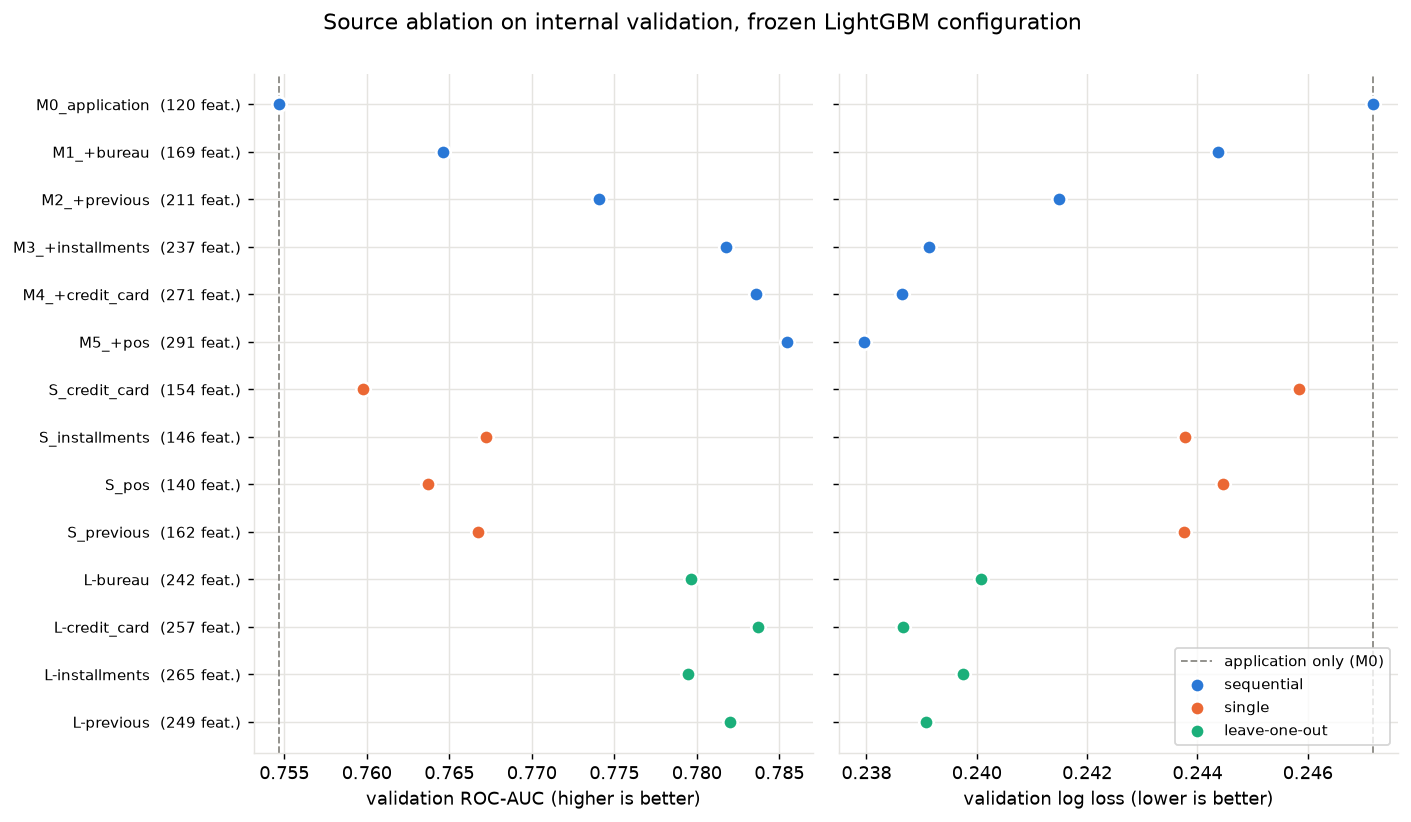

In [6]:
ablation = pd.read_csv(paths.ablation_path)
show = ["configuration", "group", "n_features", "roc_auc", "pr_auc", "log_loss", "brier", "brier_skill", "ece", "fit_seconds"]
display(ablation[show].round(5).style.hide(axis="index").highlight_min(subset=["log_loss"], color="#fde9d9").highlight_max(subset=["roc_auc", "pr_auc"], color="#fde9d9"))
display(Image(filename=str(config.PROJECT_ROOT / "artifacts/figures/relational_ablation_validation.png"), width=1000))

In [7]:
sv = pd.DataFrame(selection["source_value"]).T
sv.columns = ["history coverage", "features", "single-source Δ log loss", "single-source Δ ROC-AUC", "leave-one-out cost log loss", "leave-one-out cost ROC-AUC"]
display(sv.round(5))

,history coverage,features,single-source Δ log loss,single-source Δ ROC-AUC,leave-one-out cost log loss,leave-one-out cost ROC-AUC
bureau,0.85674,49.0,0.00280,0.00996,0.00211,0.00584
previous,0.94645,42.0,0.00341,0.01207,0.00113,0.00347
installments,0.94843,26.0,0.00340,0.01252,0.00179,0.00603
credit_card,0.28326,34.0,0.00134,0.00508,0.00070,0.00176
pos,0.94125,20.0,0.00271,0.00901,0.00069,0.00192


**Reading.** Every table adds information, and the cumulative sequence is monotone on all six metrics: validation log loss falls from 0.24717 (application only) to 0.24437 (+bureau), 0.24148 (+previous), 0.23914 (+installments), 0.23864 (+credit card) and 0.23796 (all five); ROC-AUC rises from 0.7547 to 0.7855 and PR-AUC from 0.2380 to 0.2760, while the Brier skill score goes from 0.083 to 0.108 and the validation calibration slope from 0.973 to 0.995 (the richer model is *less* under-confident, not more). Single-source models rank the standalone value of the tables: previous applications and installment payments are the strongest (each about −0.0034 log loss and +0.012 ROC-AUC on their own), bureau next (−0.0028, +0.010), POS close behind (−0.0027, +0.009) and credit cards last (−0.0013, +0.005, with only 28 % coverage). Leave-one-out costs are smaller than single-source gains for every source, which is the signature of overlapping information: the three tables that describe previous Home Credit loans (previous, installments, POS) partly stand in for each other, and bureau, the only external source, is the one whose removal costs the most conditional on all the others (+0.0021 log loss, −0.006 ROC-AUC).

## 6. Source retention: backward elimination with a validation bootstrap

A source is dropped only when removing it from the current set costs nothing on
validation log loss: the candidate is the source with the smallest removal cost, and it
is dropped when the 95 % paired-bootstrap interval of that cost (500 resamples of the
validation rows) includes zero. The elimination stops at the first source whose
removal reliably hurts.

In [8]:
for i, rnd in enumerate(selection["elimination"]["rounds"], start=1):
    cands = pd.DataFrame(rnd["candidates"])[["source", "config", "removal_cost_log_loss", "ci_low", "ci_high", "removal_cost_roc_auc", "fraction_worse_without"]]
    display(Markdown(f"**Round {i}** — full set `{rnd['full_config']}` ({', '.join(rnd['remaining_before'])}); weakest: `{rnd['weakest']}` → dropped: **{rnd['dropped']}**"))
    display(cands.round(5).style.hide(axis="index"))
print("retained sources:", selection["retained_sources"], "| configuration:", selection["retained_config"])

**Round 1** — full set `M5_+pos` (bureau, previous, installments, credit_card, pos); weakest: `pos` → dropped: **False**

source,config,removal_cost_log_loss,ci_low,ci_high,removal_cost_roc_auc,fraction_worse_without
bureau,L-bureau,0.002110,0.001540,0.002680,0.005840,1.000000
previous,L-previous,0.001130,0.000660,0.001650,0.003470,1.000000
installments,L-installments,0.001790,0.001240,0.002360,0.006030,1.000000
credit_card,L-credit_card,0.000700,0.000240,0.001200,0.001760,0.996000
pos,M4_+credit_card,0.000690,0.000290,0.001050,0.001920,1.000000


retained sources: ['bureau', 'previous', 'installments', 'credit_card', 'pos'] | configuration: M5_+pos


**Reading.** The elimination stopped at the first round: the weakest source is POS (removing it from the full set costs +0.00069 log loss, 95 % interval [+0.00029, +0.00105], worse in 100 % of the 500 validation resamples), and every other removal costs more with an interval clear of zero (credit card +0.00070 [+0.00024, +0.00120]; previous +0.00113; installments +0.00179; bureau +0.00211). No source is redundant given the others, so all five are retained and the final feature set is the 291-column matrix. The two cheapest sources to drop, POS and credit card, are also the ones with the most overlap (POS with installments) and the least coverage (credit card); they earn their place, but by a margin one should remember when weighing the 60 % longer fit of the full model.

## 7. Light retuning on the retained feature set

Four two-value axes (leaves, minimum leaf size, feature fraction, L2) explored by the
same coordinate descent as Milestone 2, with early stopping on validation log loss
(learning rate 0.02, patience 100). The purpose is to avoid penalising the wider
feature space with parameters chosen for 120 columns, not to search.

In [9]:
retune = selection["retune"]
trials = pd.read_csv(paths.trials_path)
cols = ["trial_id", "stage", "description", "n_features", "n_trees", "fit_seconds", "val_log_loss", "val_roc_auc", "val_average_precision", "val_expected_calibration_error"]
display(trials[cols].round(5).style.hide(axis="index").highlight_min(subset=["val_log_loss"], color="#fde9d9"))
print("frozen configuration on the same features (fixed 1,380 rounds):", {k: round(v, 5) for k, v in retune["frozen_configuration_validation_metrics"].items() if k in ("roc_auc", "pr_auc", "log_loss")})
print("selected trial:", retune["selected_trial"], "| changes vs the frozen configuration:", retune["changed_vs_frozen"])

trial_id,stage,description,n_features,n_trees,fit_seconds,val_log_loss,val_roc_auc,val_average_precision,val_expected_calibration_error
lightgbm-01,initial,starting configuration,291,1802,111.320000,0.237770,0.786150,0.276290,0.005250
lightgbm-02,search:num_leaves,num_leaves=31,291,1178,82.160000,0.237810,0.785980,0.276440,0.005570
lightgbm-03,search:min_child_samples,min_child_samples=100,291,1886,85.370000,0.238330,0.784320,0.274860,0.006080
lightgbm-04,search:colsample_bytree,colsample_bytree=0.3,291,2635,87.630000,0.237530,0.787350,0.275770,0.005660
lightgbm-05,search:reg_lambda,reg_lambda=10.0,291,2244,42.830000,0.237680,0.786900,0.274860,0.005200


frozen configuration on the same features (fixed 1,380 rounds): {'roc_auc': 0.78549, 'pr_auc': 0.27604, 'log_loss': 0.23796}
selected trial: lightgbm-04 | changes vs the frozen configuration: {'colsample_bytree': {'frozen': 0.5, 'retuned': 0.3}, 'n_estimators': {'frozen': 1380, 'retuned': 2635}}


**Reading.** With early stopping the frozen recipe itself wants more rounds on 291 features (1,802 instead of 1,380, log loss 0.23777 vs 0.23796 at fixed rounds); of the four axes only the feature fraction moved the needle: 30 % of the features per tree (0.23753, 2,635 rounds) beat 50 %, while 31 leaves, a smaller minimum leaf and a stronger L2 were all slightly worse. The locked configuration therefore keeps the Milestone 2 recipe except `colsample_bytree` 0.5 → 0.3 and the round count 1,380 → 2,635. The whole exercise is worth 0.0004 in validation log loss, a tenth of what the weakest data source is worth: better information, not better tuning, is what moved this milestone.

## 8. Frozen test comparison

The locked feature set and configuration are refitted on the whole training portion
(246,008 rows) and scored once on the frozen test split, next to the persisted
Milestone 1 Logistic Regression and the persisted Milestone 2 application-only LightGBM,
both reloaded from disk and required to reproduce their recorded metrics. This cell
re-executes the final stage and checks it against the command-line run.

INFO riskpilot.features.relational.assemble: bureau: 49 features joined, 85.7% of rows have history


INFO riskpilot.features.relational.assemble: previous: 42 features joined, 94.6% of rows have history


INFO riskpilot.features.relational.assemble: installments: 26 features joined, 94.8% of rows have history


INFO riskpilot.features.relational.assemble: credit_card: 34 features joined, 28.3% of rows have history


INFO riskpilot.features.relational.assemble: pos: 20 features joined, 94.1% of rows have history


...

INFO riskpilot.models.relational_experiment: Final lightgbm_relational on the frozen test split: ROC-AUC 0.7900 | PR-AUC 0.2943 | log loss 0.23535 | Brier 0.06532 | ECE 0.0023


notebook refit reproduces the command-line test metrics: True (trees 2635 vs 2635)
reference integrity: {'logistic_regression': True, 'lightgbm': True}


,n_features,roc_auc,average_precision,log_loss,brier_score,brier_skill_score,expected_calibration_error
model,,,,,,,
Logistic Regression,312,0.7504,0.2353,0.2482,0.0682,0.0808,0.0021
LightGBM,120,0.7622,0.2538,0.2446,0.0674,0.0919,0.0022
LightGBM + history,291,0.7900,0.2943,0.2354,0.0653,0.1199,0.0023


,Δ vs app-only LightGBM: roc_auc,Δ vs app-only LightGBM: average_precision,Δ vs app-only LightGBM: log_loss,Δ vs app-only LightGBM: brier_score,Δ vs LR: roc_auc,Δ vs LR: average_precision,Δ vs LR: log_loss,Δ vs LR: brier_score
model,,,,,,,,
Logistic Regression,-0.0118,-0.0185,0.0036,0.0008,0.0000,0.0000,0.0000,0.0000
LightGBM,0.0000,0.0000,0.0000,0.0000,0.0118,0.0185,-0.0036,-0.0008
LightGBM + history,0.0278,0.0405,-0.0092,-0.0021,0.0396,0.0590,-0.0129,-0.0029


,n_trees,fit_seconds,predict_seconds_test,model_size_mb,train_roc_auc,train_log_loss
model,,,,,,
Logistic Regression,NaN,32.10,0.567,0.027,0.751228,0.248407
LightGBM,1380.0,37.21,1.696,2.552,0.802706,0.232883
LightGBM + history,2635.0,102.28,2.966,4.885,0.859661,0.209576


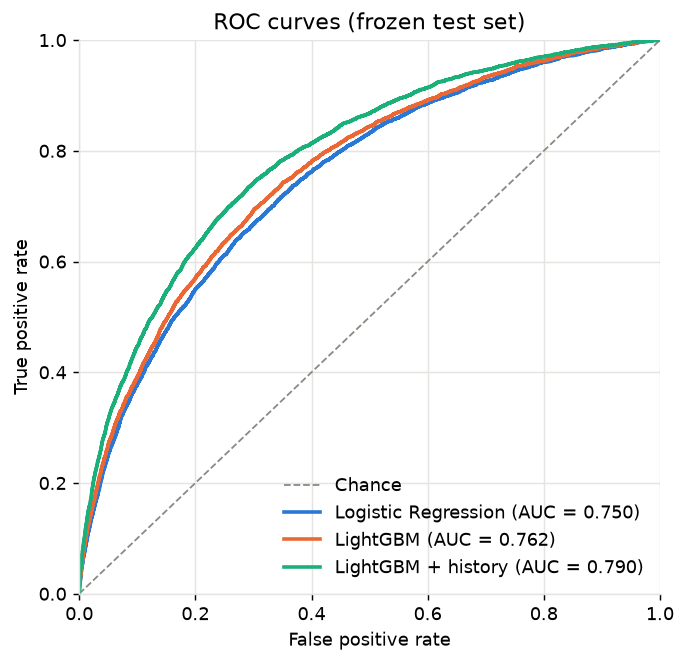

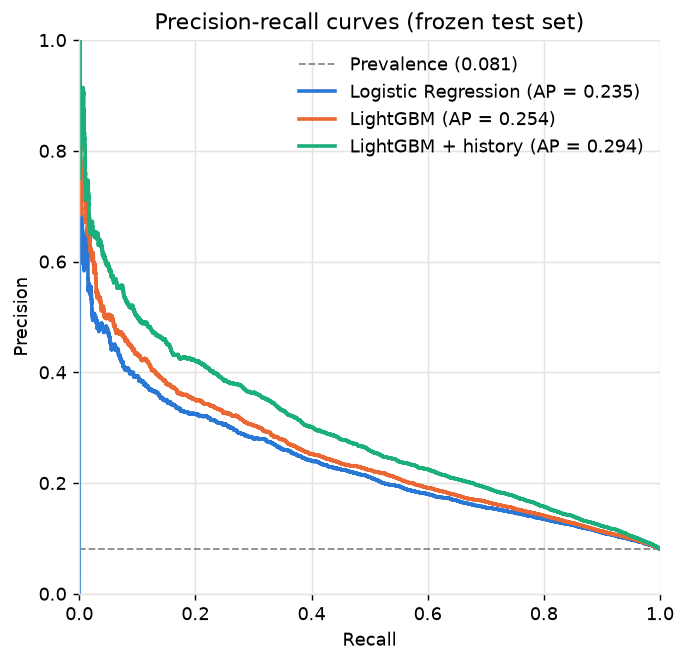

In [10]:
previous = json.loads(paths.final_metrics_path.read_text(encoding="utf-8"))
final = rx.run_final_stage(split, selection, paths, rx.AblationConfig(n_bootstrap_test=1000))
payload = final["payload"]
same = all(np.isclose(payload["metrics"]["test"][k], previous["metrics"]["test"][k], atol=1e-9) for k in KEYS)
print("notebook refit reproduces the command-line test metrics:", same, f"(trees {payload['model']['n_trees']} vs {previous['model']['n_trees']})")
print("reference integrity:", {k: v["metrics_match_recorded"] for k, v in payload["references"].items()})
table = final["comparison_table"].set_index("model")
main = ["n_features", "roc_auc", "average_precision", "log_loss", "brier_score", "brier_skill_score", "expected_calibration_error"]
display(table[main].round(4))
deltas = table[[f"delta_{k}" for k in cmp.BOOTSTRAP_METRICS] + [f"delta_vs_lr_{k}" for k in cmp.BOOTSTRAP_METRICS]].round(4)
deltas.columns = [c.replace("delta_vs_lr_", "Δ vs LR: ").replace("delta_", "Δ vs app-only LightGBM: ") for c in deltas.columns]
display(deltas)
display(table[["n_trees", "fit_seconds", "predict_seconds_test", "model_size_mb", "train_roc_auc", "train_log_loss"]])
for key in ("roc_comparison", "precision_recall_comparison"):
    display(Image(filename=str(config.PROJECT_ROOT / payload["artifacts"]["figures"][key]), width=480))

**Reading.** On the identical 61,503 frozen test rows the relational model reaches ROC-AUC 0.7900, PR-AUC 0.2943, log loss 0.2354, Brier 0.0653, Brier skill 0.120 and ECE 0.0023, against 0.7622 / 0.2538 / 0.2446 / 0.0674 / 0.092 / 0.0022 for the application-only LightGBM and 0.7504 / 0.2353 / 0.2482 / 0.0682 / 0.081 / 0.0021 for the Logistic Regression baseline (both reloaded from disk and reproducing their recorded metrics to 1e-6). Relative to the application-only model that is +0.028 ROC-AUC (+3.6 %), +0.041 PR-AUC (+16 %), −3.8 % log loss and −3.1 % Brier: the historical tables are worth about two and a half times what the change of model class was worth in Milestone 2 (+0.012 ROC-AUC), and both proper scores improve with discrimination. Relative to the Milestone 1 baseline the cumulative gain is +0.040 ROC-AUC and +0.059 PR-AUC. The costs are real but small: 105 s to fit (2,635 rounds on 291 columns) against 37 s, 3.1 s to score the test split against 1.5 s, a 4.9 MB pipeline against 2.6 MB, and a wider train–test gap (train ROC-AUC 0.860 vs test 0.790) that the calibration diagnostics below show is not over-confidence on unseen rows. The notebook refit reproduces the command-line metrics to the last digit.

## 9. Uncertainty and calibration

Paired bootstrap on the frozen test predictions (1,000 resamples, seed 42; every model
scored on the same resample), then the reliability tables and the slope / intercept
diagnostic. Nothing here alters the predictions.

,comparison,metric,difference,ci95_low,ci95_high,bootstrap_sd,fraction_improving,ci_excludes_zero
0,Logistic Regression − LightGBM,roc_auc,-0.01179,-0.01448,-0.00917,0.00133,0.0,True
1,Logistic Regression − LightGBM,average_precision,-0.01849,-0.02355,-0.01302,0.00269,0.0,True
2,Logistic Regression − LightGBM,log_loss,0.00365,0.00296,0.00436,0.00037,0.0,True
3,Logistic Regression − LightGBM,brier_score,0.00083,0.00063,0.00102,0.00010,0.0,True
4,LightGBM + history − LightGBM,roc_auc,0.02780,0.02380,0.03158,0.00200,1.0,True
5,LightGBM + history − LightGBM,average_precision,0.04050,0.03319,0.04823,0.00388,1.0,True
6,LightGBM + history − LightGBM,log_loss,-0.00920,-0.01045,-0.00797,0.00062,1.0,True
7,LightGBM + history − LightGBM,brier_score,-0.00207,-0.00242,-0.00174,0.00017,1.0,True
8,LightGBM + history − Logistic Regression,roc_auc,0.03959,0.03530,0.04409,0.00228,1.0,True
9,LightGBM + history − Logistic Regression,average_precision,0.05899,0.05054,0.06862,0.00443,1.0,True


re-running the bootstrap with seed 42 reproduces every interval: True


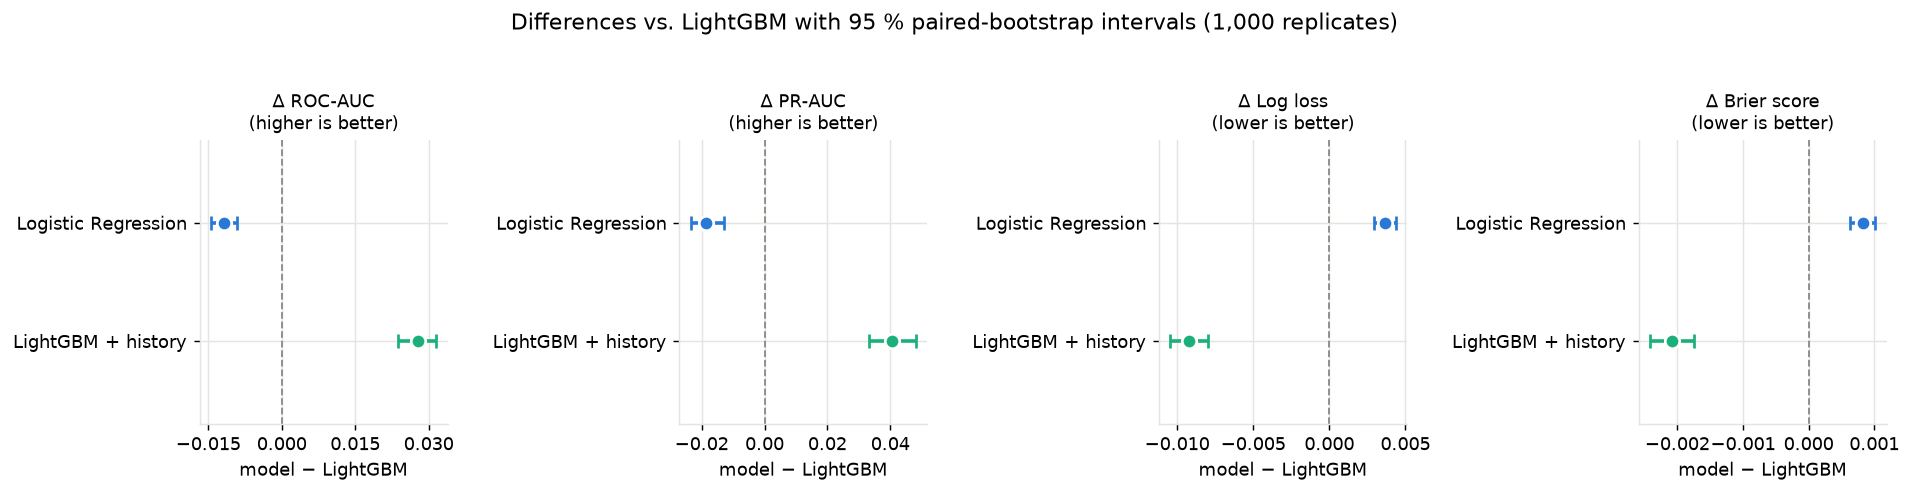

In [11]:
boot = final["bootstrap"]
rows = []
for pair, entry in boot["differences"].items():
    for metric in boot["metrics"]:
        s = entry[metric]
        rows.append({"comparison": f"{LABEL[entry['model']]} − {LABEL[entry['reference']]}", "metric": metric,
                     "difference": s["estimate"], "ci95_low": s["ci_low"], "ci95_high": s["ci_high"],
                     "bootstrap_sd": s["bootstrap_sd"], "fraction_improving": s["fraction_improving"], "ci_excludes_zero": s["ci_excludes_zero"]})
display(pd.DataFrame(rows).round(5))
again = cmp.paired_bootstrap(split.y_test.to_numpy(), final["predictions"], n_replicates=boot["n_replicates"], seed=boot["seed"], reference=rx.APP_ONLY_KEY)
same = all(again["differences"][p][m][k] == boot["differences"][p][m][k] for p in boot["differences"] for m in boot["metrics"] for k in ("ci_low", "ci_high"))
print(f"re-running the bootstrap with seed {boot['seed']} reproduces every interval: {same}")
display(Image(filename=str(config.PROJECT_ROOT / payload["artifacts"]["figures"]["delta_bootstrap"]), width=1000))

Logistic Regression                             LightGBM                       LightGBM + history                      
         mean_predicted observed_rate     gap mean_predicted observed_rate     gap     mean_predicted observed_rate     gap
bin                                                                                                                        
0                0.0119        0.0150  0.0031         0.0135        0.0124 -0.0012             0.0096        0.0098  0.0001
1                0.0214        0.0215  0.0001         0.0217        0.0202 -0.0016             0.0166        0.0163 -0.0004
2                0.0299        0.0291 -0.0008         0.0289        0.0285 -0.0005             0.0232        0.0211 -0.0020
3                0.0390        0.0358 -0.0032         0.0370        0.0351 -0.0018             0.0307        0.0311  0.0004
4                0.0495        0.0491 -0.0004         0.0466        0.0433 -0.0034             0.0402        0.0392 -0.0010
5                0.0624        0.0613 -0.0011         0.0590        0.0592  0.0002             0.0526        0.0504 -0.0022
6                0.0797        0.0800  0.0003         0.0759        0.0802  0.0043             0.0701        0.0699 -0.0001
7                0.1042        0.1033 -0.0010         0.1009        0.0995 -0.0014             0.0975        0.1050  0.0076
8                0.1449        0.1420 -0.0030         0.1446        0.1496  0.0050             0.1486        0.1551  0.0066
9                0.2623        0.2704  0.0081         0.2769        0.2795  0.0026             0.3122        0.3094 -0.0029

,Logistic Regression,LightGBM,LightGBM + history
mean predicted,0.0805,0.0805,0.0801
observed prevalence,0.0807,0.0807,0.0807
calibration slope,1.0056,1.0220,1.0010
calibration intercept,0.0148,0.0491,0.0113
ECE (10 quantile bins),0.0021,0.0022,0.0023
max predicted,0.7443,0.7844,0.8620
n test rows scored > 0.5,108.0000,197.0000,513.0000


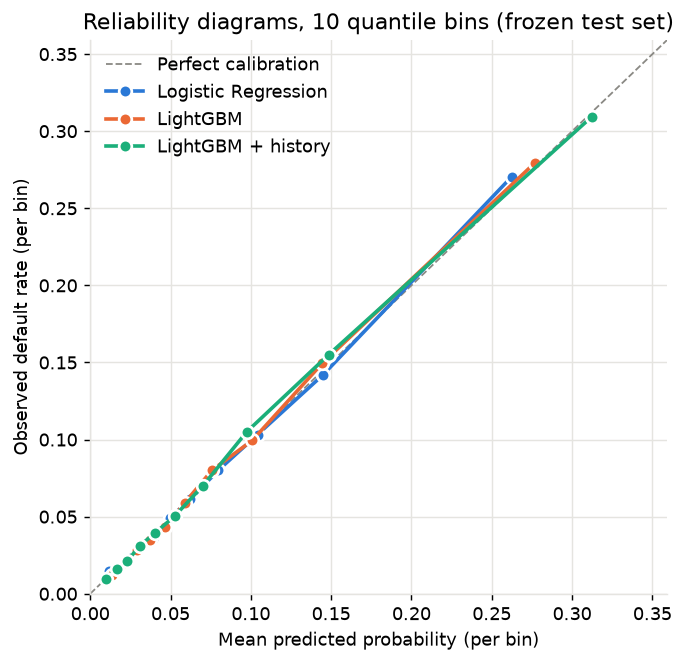

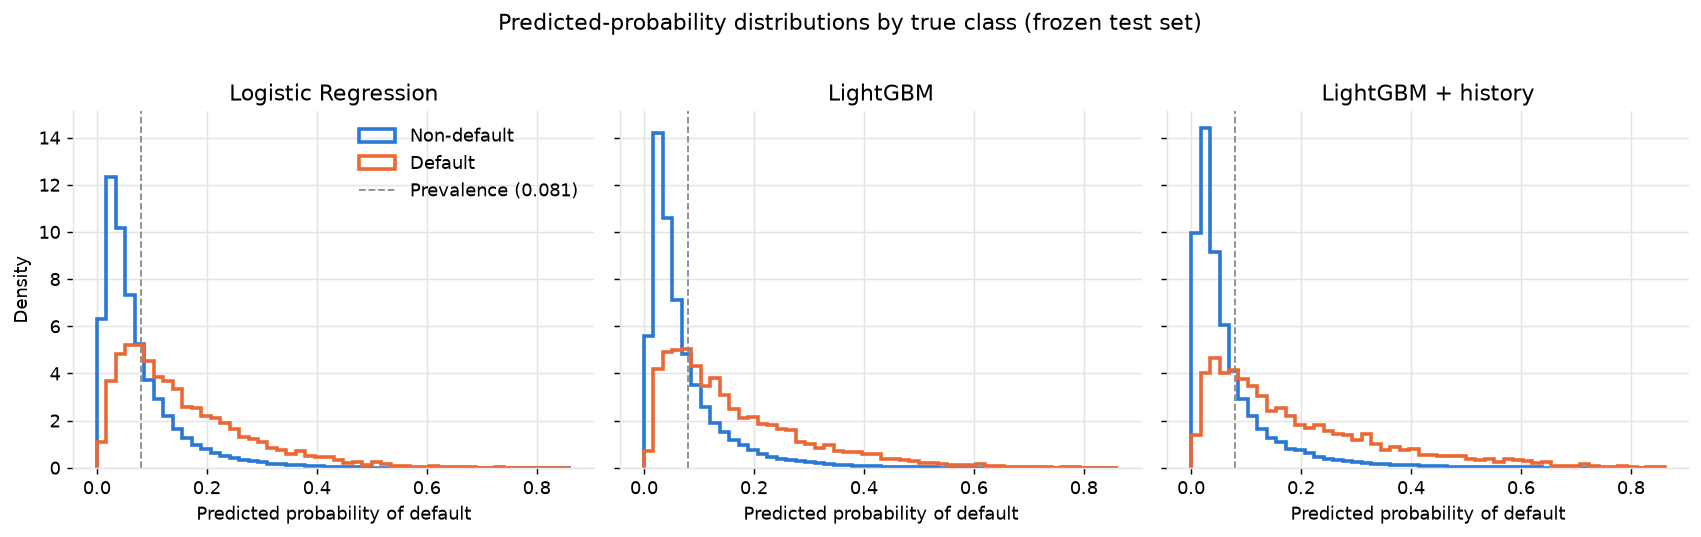

In [12]:
preds = final["predictions"]
y_test = split.y_test.to_numpy()
rel = {LABEL[name]: calibration_table(y_test, p, n_bins=10).set_index("bin")[["mean_predicted", "observed_rate", "gap"]] for name, p in preds.items()}
display(pd.concat(rel, axis=1).round(4))
summaries = {k: v for k, v in zip(preds, [final["references"]["logistic_regression"].summary, final["references"][rx.APP_ONLY_KEY].summary, {"metrics_test": payload["metrics"]["test"]}], strict=True)}
diag = pd.DataFrame({LABEL[k]: {
    "mean predicted": v["metrics_test"]["mean_predicted_probability"],
    "observed prevalence": float(y_test.mean()),
    "calibration slope": v["metrics_test"]["calibration_slope"],
    "calibration intercept": v["metrics_test"]["calibration_intercept"],
    "ECE (10 quantile bins)": v["metrics_test"]["expected_calibration_error"],
    "max predicted": v["metrics_test"]["max_predicted_probability"],
    "n test rows scored > 0.5": int((preds[k] > 0.5).sum()),
} for k, v in summaries.items()})
display(diag.round(4))
for key in ("calibration_comparison", "probability_distributions"):
    display(Image(filename=str(config.PROJECT_ROOT / payload["artifacts"]["figures"][key]), width=560 if key == "calibration_comparison" else 900))

**Reading.** Every difference has a 95 % paired-bootstrap interval well clear of zero and the relational model wins on every one of the 1,000 resamples: vs the application-only LightGBM, Δ ROC-AUC +0.0278 [+0.0238, +0.0316], Δ PR-AUC +0.0405 [+0.0332, +0.0482], Δ log loss −0.0092 [−0.0105, −0.0080], Δ Brier −0.0021 [−0.0024, −0.0017]; vs the Logistic Regression baseline, +0.0396 [+0.0353, +0.0441], +0.0590 [+0.0505, +0.0686], −0.0129 [−0.0143, −0.0115], −0.0029 [−0.0033, −0.0025]. The lower bounds sit about twelve bootstrap standard deviations from zero, so the gain is stable across resamples of this holdout. Calibration is preserved and, if anything, slightly better: mean prediction 0.0801 vs 0.0807 observed, slope 1.001, intercept 0.011, ECE 0.0023 against 0.0022 for the application-only model, and the largest decile gap stays below one percentage point. The richer model spreads its probabilities further (maximum 0.86 vs 0.78; more applicants above 0.5) without leaving the diagonal: it is neither over- nor under-confident, and formal recalibration still has nothing to correct on this evidence.

## 10. Feature-source interpretation (tree-based importance) and leakage audit

Gain and split importance of the final model aggregated by source: an engineering
sanity check that the relational groups are actually used, **not** a causal or
explanatory statement (that is a later milestone). Then the audit: which functions
touch the test partition, that the selection stages cannot receive it, and that no
identifier or target ever enters a feature frame.

,source,n_features,gain,split,gain_share,split_share,features_used,top_features_by_gain
0,application,120,422546.0285,14786,0.5335,0.4008,103,"EXT_SOURCE_2, EXT_SOURCE_3, ORGANIZATION_TYPE"
1,bureau,49,109076.1695,6869,0.1377,0.1862,46,"bureau__debt_to_credit_ratio, bureau__days_credit_max, bureau__days_credit_mean"
2,previous,42,93246.0914,5719,0.1177,0.1550,41,"previous__credit_to_application_ratio_mean, previous__refusal_rate, previous__amt_annu..."
3,installments,26,75627.1026,4130,0.0955,0.1120,25,"installments__late_rate_12m, installments__late_rate, installments__paid_sum"
4,credit_card,34,45396.5132,2469,0.0573,0.0669,32,"credit_card__utilization_latest_mean, credit_card__over_limit_rate, credit_card__atm_d..."
5,pos,20,46167.2657,2917,0.0583,0.0791,19,"pos__remaining_share_mean, pos__instalments_future_mean, pos__instalments_future_max"


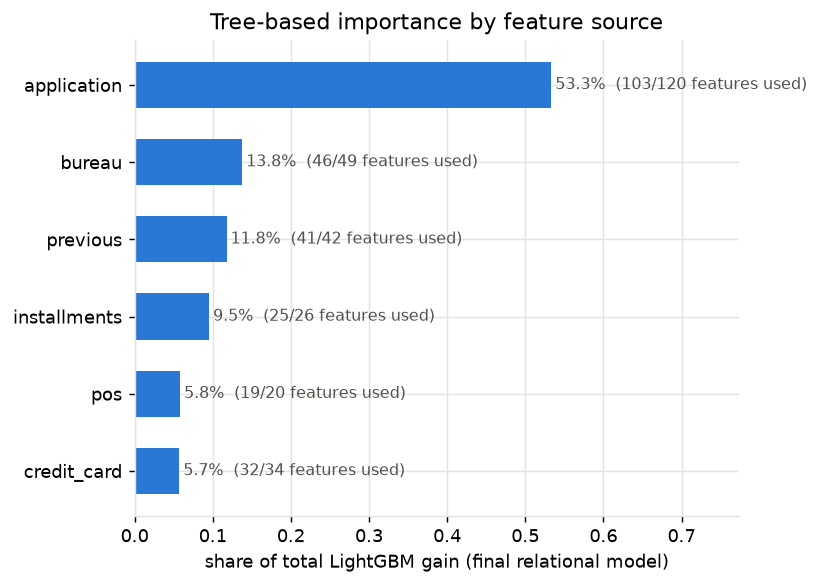

run_ablation_stage (X_train: 'pd.DataFrame', y_train: 'pd.Series', ids_train: 'pd.Series', paths: 'RelationalPaths', cfg: 'AblationConfig | None' = None, *, resume: 'bool' = False) -> 'dict[str, Any]'
run_retune_stage   (X_train: 'pd.DataFrame', y_train: 'pd.Series', ids_train: 'pd.Series', selection: 'dict[str, Any]', paths: 'RelationalPaths', cfg: 'AblationConfig | None' = None) -> 'dict[str, Any]'
functions in riskpilot.models.relational_experiment whose source touches X_test: ['run_final_stage']
functions in riskpilot.features.relational.assemble whose source touches X_test: []
identifier or target among the final model's features: []
relational features whose catalog row is not 'safe': 0
early stopping in the final refit: none (rounds locked during selection) | preprocessing fitted on: training portion only (TreePreprocessor inside fit_challenger)


In [13]:
display(final["importance"].round(4))
display(Image(filename=str(config.PROJECT_ROOT / payload["artifacts"]["figures"]["importance_by_source"]), width=640))
print("run_ablation_stage", inspect.signature(rx.run_ablation_stage))
print("run_retune_stage  ", inspect.signature(rx.run_retune_stage))
for mod in (rx, assemble):
    touching = [n for n, f in inspect.getmembers(mod, inspect.isfunction) if f.__module__ == mod.__name__ and "X_test" in inspect.getsource(f)]
    print(f"functions in {mod.__name__} whose source touches X_test: {touching}")
feature_names = list(joblib.load(paths.model_path)["preprocess"].get_feature_names_out())
print("identifier or target among the final model's features:", [c for c in feature_names if c in (config.ID_COL, config.TARGET_COL)])
print("relational features whose catalog row is not 'safe':", int((~catalog["leakage_assessment"].str.startswith("safe")).sum()))
print("early stopping in the final refit:", payload["model"]["early_stopping"], "| preprocessing fitted on: training portion only (TreePreprocessor inside fit_challenger)")

## 11. Conclusions

* **Better information beats better modelling.** On the same 61,503 frozen test rows, the five historical tables lift LightGBM from ROC-AUC 0.762 to **0.790** and PR-AUC from 0.254 to **0.294**, cut log loss by 3.8 % and Brier by 3.1 %, with 95 % paired-bootstrap intervals well clear of zero. That is roughly 2.4 × the gain the model class produced in Milestone 2, and it comes with calibration intact (ECE 0.0023, slope 1.00, mean prediction equal to the prevalence).
* **Every source earns its place, unevenly.** Standalone, previous applications and installment payments are the most informative, bureau records next, POS behind, credit cards last (28 % coverage). Conditional on the others, the external bureau history is the hardest to replace and the three Home Credit tables overlap; POS and credit card are the cheapest to drop but still cost a reliable +0.0007 log loss each, so backward elimination retained all five.
* **Tuning is a footnote.** The wider feature space only asked for a smaller feature fraction (0.3) and more rounds (2,635); the retune was worth 0.0004 in validation log loss, a tenth of the weakest source.
* **Leakage-safe by construction, audited in code.** Every time anchor is at most 0 on every row, the five ambiguous schedule columns were excluded, split payments are merged before aggregation, every join is validated one-to-one, identifiers and `TARGET` are refused, and the frozen test split was scored once, after the feature set and the configuration were locked on validation data.
* **What remains.** The random (not temporal) holdout still measures interpolation within the period; the per-row memory of this laptop shaped the design (one table at a time, `float32`, cached parquet) but not the method; and the relational aggregates are first-generation (no trend or time-window families beyond the last 12 months). The model now reaches the level of published solutions on this competition with a fraction of their feature count.
* **Recommendation.** The production candidate is the relational LightGBM. Because its probabilities are already calibrated and the class prior is unchanged, the next milestone should turn them into decisions: the cost-sensitive decision engine (expected-loss thresholds, approve / review / decline) on the frozen test split, with the calibration check kept as a gate rather than a separate milestone.